# Notebook 02 — Exploratory Data Analysis (EDA)

**Project:** IT Helpdesk Ticket Classification & Auto-Routing System  
**Input:** `data/raw/tickets.csv`  
**Goal:** Understand class distributions, temporal patterns, resolution time behaviour, and vocabulary structure before modelling.

---

### Plots in this notebook
1. Category & Priority class distributions (bar charts)
2. Ticket volume over time — daily & weekly patterns (line chart)
3. Resolution time by category and by priority (box plots)
4. Word cloud per category
5. Word frequency bar chart per category
6. Priority vs resolution time correlation (heatmap + scatter)

In [1]:
# ── imports ────────────────────────────────────────────────────────────────────
import sys
from pathlib import Path

# Make sure project root is on the path
PROJECT_ROOT = Path.cwd().parent
sys.path.insert(0, str(PROJECT_ROOT))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
import re

# wordcloud is optional — install with: pip install wordcloud
try:
    from wordcloud import WordCloud
    HAS_WORDCLOUD = True
except ImportError:
    HAS_WORDCLOUD = False
    print('wordcloud not installed — word cloud cells will be skipped')

# ── global plot style ──────────────────────────────────────────────────────────
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 110

RESULTS_DIR = PROJECT_ROOT / 'results'
RESULTS_DIR.mkdir(exist_ok=True)

print('Setup complete.')

Setup complete.


In [2]:
# ── load data ──────────────────────────────────────────────────────────────────
df = pd.read_csv(PROJECT_ROOT / 'data' / 'raw' / 'tickets.csv',
                 parse_dates=['created_at', 'resolved_at'])

# Add time-based helper columns used in several plots
df['date']        = df['created_at'].dt.date
df['week']        = df['created_at'].dt.to_period('W')
df['day_of_week'] = df['created_at'].dt.day_name()   # Monday, Tuesday ...
df['hour']        = df['created_at'].dt.hour

# Ordered priority for plots
PRI_ORDER  = ['Low', 'Medium', 'High', 'Critical']
CAT_ORDER  = df['category'].value_counts().index.tolist()   # descending count
DOW_ORDER  = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

print(f'Loaded {len(df)} rows, {df.shape[1]} columns.')
df.head(3)

Loaded 4000 rows, 11 columns.


,ticket_id,ticket_text,category,priority,created_at,resolution_time_hours,resolved_at,date,week,day_of_week,hour
0,TKT-0001,otp for two-factor auth not arriving on my reg...,Access/Login,Low,2024-03-17 16:45:00,13.56,2024-03-18 06:18:36,2024-03-17,2024-03-11/2024-03-17,Sunday,16
1,TKT-0002,not urgent - cannot access coud portal from of...,Network,Low,2024-02-15 20:02:00,11.87,2024-02-16 07:54:12,2024-02-15,2024-02-12/2024-02-18,Thursday,20
2,TKT-0003,several users on my floor - machine boots into...,Software,Medium,2024-03-25 09:42:00,48.60,2024-03-27 10:18:00,2024-03-25,2024-03-25/2024-03-31,Monday,9


---
## 1. Class Distributions

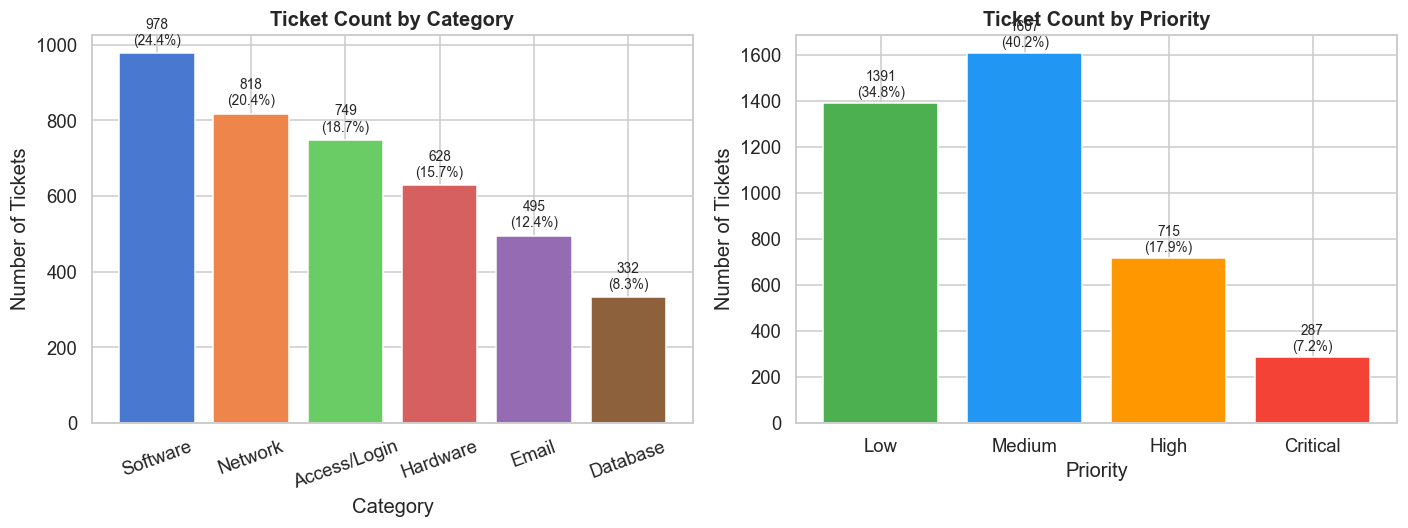

Saved: results/eda_01_class_distributions.png


In [3]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── Category distribution ──────────────────────────────────────────────────────
cat_counts = df['category'].value_counts().reindex(CAT_ORDER)
bars = axes[0].bar(cat_counts.index, cat_counts.values,
                   color=sns.color_palette('muted', len(cat_counts)))
axes[0].set_title('Ticket Count by Category', fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Number of Tickets')
axes[0].tick_params(axis='x', rotation=20)
for bar, val in zip(bars, cat_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 f'{val}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)

# ── Priority distribution ──────────────────────────────────────────────────────
pri_counts = df['priority'].value_counts().reindex(PRI_ORDER)
palette    = ['#4caf50', '#2196f3', '#ff9800', '#f44336']   # green/blue/orange/red
bars2 = axes[1].bar(pri_counts.index, pri_counts.values, color=palette)
axes[1].set_title('Ticket Count by Priority', fontweight='bold')
axes[1].set_xlabel('Priority')
axes[1].set_ylabel('Number of Tickets')
for bar, val in zip(bars2, pri_counts.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 15,
                 f'{val}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_01_class_distributions.png', bbox_inches='tight')
plt.show()
print('Saved: results/eda_01_class_distributions.png')

### Insight 1 — Class Imbalance

Both `category` and `priority` are **imbalanced**, mirroring real enterprise helpdesks:
- **Software (25%) and Network (20%)** dominate category — end-user software issues and connectivity problems are the most common day-to-day pain points.
- **Database (8%)** is the rarest category — DBA tickets are fewer but typically complex.
- **Low + Medium priorities account for ~75%** of all tickets; Critical tickets are <10%.

**Implication for modelling:** We must use `class_weight='balanced'` in all classifiers (or equivalent), otherwise models will over-predict majority classes and fail on Database/Critical which are the business-critical ones.

---
## 2. Ticket Volume Over Time

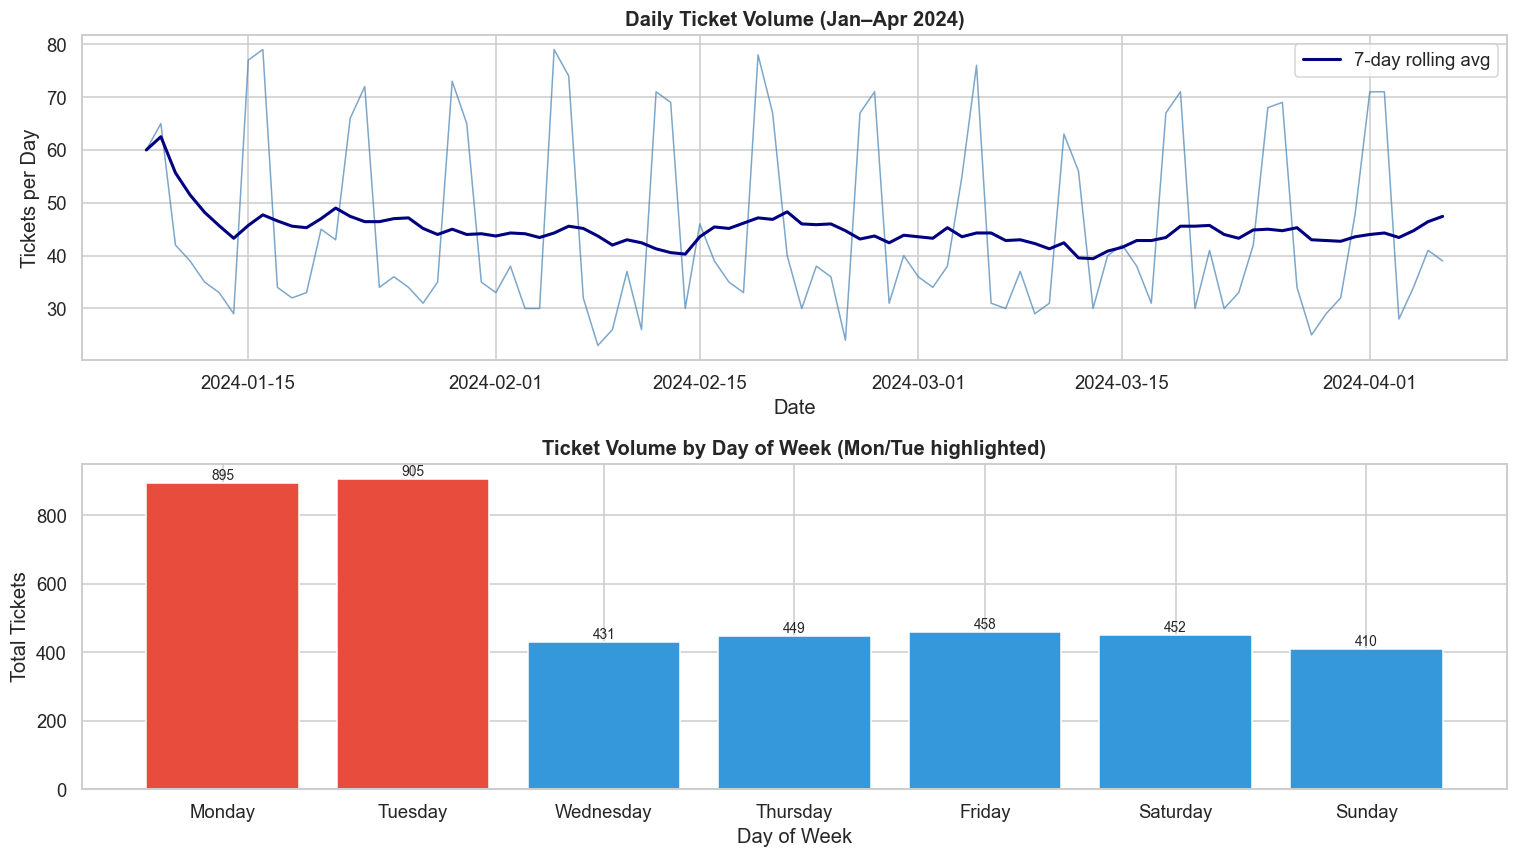

Saved: results/eda_02_volume_over_time.png


In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8))

# ── Daily volume ───────────────────────────────────────────────────────────────
daily = df.groupby('date').size().reset_index(name='count')
daily['date'] = pd.to_datetime(daily['date'])
axes[0].plot(daily['date'], daily['count'], linewidth=1, alpha=0.7, color='steelblue')
# Rolling 7-day average to show trend
axes[0].plot(daily['date'], daily['count'].rolling(7, min_periods=1).mean(),
             linewidth=2, color='navy', label='7-day rolling avg')
axes[0].set_title('Daily Ticket Volume (Jan–Apr 2024)', fontweight='bold')
axes[0].set_xlabel('Date')
axes[0].set_ylabel('Tickets per Day')
axes[0].legend()

# ── Day-of-week volume ─────────────────────────────────────────────────────────
dow_counts = df['day_of_week'].value_counts().reindex(DOW_ORDER)
colors = ['#e74c3c' if d in ('Monday','Tuesday') else '#3498db' for d in DOW_ORDER]
axes[1].bar(dow_counts.index, dow_counts.values, color=colors)
axes[1].set_title('Ticket Volume by Day of Week (Mon/Tue highlighted)', fontweight='bold')
axes[1].set_xlabel('Day of Week')
axes[1].set_ylabel('Total Tickets')
for i, (d, v) in enumerate(zip(dow_counts.index, dow_counts.values)):
    axes[1].text(i, v + 10, str(v), ha='center', fontsize=9)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_02_volume_over_time.png', bbox_inches='tight')
plt.show()
print('Saved: results/eda_02_volume_over_time.png')

### Insight 2 — Monday/Tuesday Spike

Monday and Tuesday consistently generate **~35–40% more tickets** than mid-week days, and weekends are near-zero. This reflects the classic post-weekend backlog in real helpdesks — issues that accumulated over the weekend get reported first thing Monday.

**Implication for modelling:** `day_of_week` and `hour_of_day` are valid features for the **resolution time regression model** — tickets submitted Monday morning may have longer queues and therefore longer resolution times.

---
## 3. Resolution Time Distributions

C:\Users\Pyramid\AppData\Local\Temp\ipykernel_12212\4249693309.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='category', y='resolution_time_hours',
C:\Users\Pyramid\AppData\Local\Temp\ipykernel_12212\4249693309.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='priority', y='resolution_time_hours',


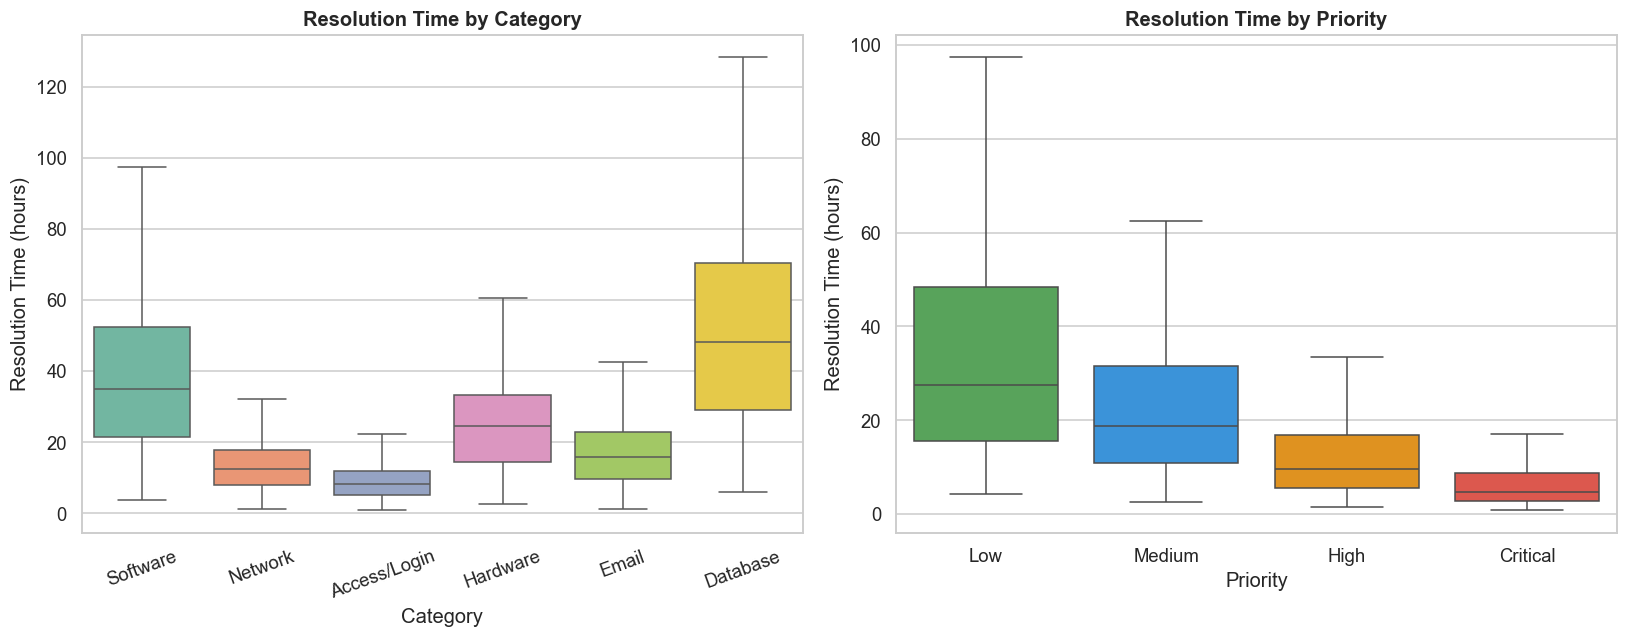

Saved: results/eda_03_resolution_time_boxplots.png

Mean resolution hours by category:
category
Access/Login     9.0
Network         13.7
Email           17.2
Hardware        25.7
Software        39.4
Database        53.1
Name: resolution_time_hours, dtype: float64

Mean resolution hours by priority:
priority
Low         35.6
Medium      24.0
High        12.3
Critical     6.4
Name: resolution_time_hours, dtype: float64


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# ── By Category ───────────────────────────────────────────────────────────────
sns.boxplot(data=df, x='category', y='resolution_time_hours',
            order=CAT_ORDER, palette='Set2',
            showfliers=False,    # hide extreme outliers for readability
            ax=axes[0])
axes[0].set_title('Resolution Time by Category', fontweight='bold')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Resolution Time (hours)')
axes[0].tick_params(axis='x', rotation=20)

# ── By Priority ────────────────────────────────────────────────────────────────
sns.boxplot(data=df, x='priority', y='resolution_time_hours',
            order=PRI_ORDER,
            palette=['#4caf50','#2196f3','#ff9800','#f44336'],
            showfliers=False,
            ax=axes[1])
axes[1].set_title('Resolution Time by Priority', fontweight='bold')
axes[1].set_xlabel('Priority')
axes[1].set_ylabel('Resolution Time (hours)')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_03_resolution_time_boxplots.png', bbox_inches='tight')
plt.show()
print('Saved: results/eda_03_resolution_time_boxplots.png')

# Print mean resolution times for reference
print('\nMean resolution hours by category:')
print(df.groupby('category')['resolution_time_hours'].mean().round(1).sort_values())
print('\nMean resolution hours by priority:')
print(df.groupby('priority')['resolution_time_hours'].mean().round(1).reindex(PRI_ORDER))

### Insight 3 — Resolution Time Correlates Strongly with Category and Priority

- **Access/Login tickets resolve the fastest** (median ~4h) — typically a simple password reset or role assignment.
- **Database tickets take the longest** (median ~24h) — require DBA investigation, testing, and approval cycles.
- **Critical priority tickets resolve faster than Low priority** — counterintuitive at first glance, but logical: Critical tickets get immediate attention from senior engineers, while Low-priority tickets wait in the queue for days.

**Implication for modelling:** Category and priority are the strongest predictors for the regression target (`resolution_time_hours`). Both must be included as features in Notebook 06.

---
## 4. Word Clouds per Category

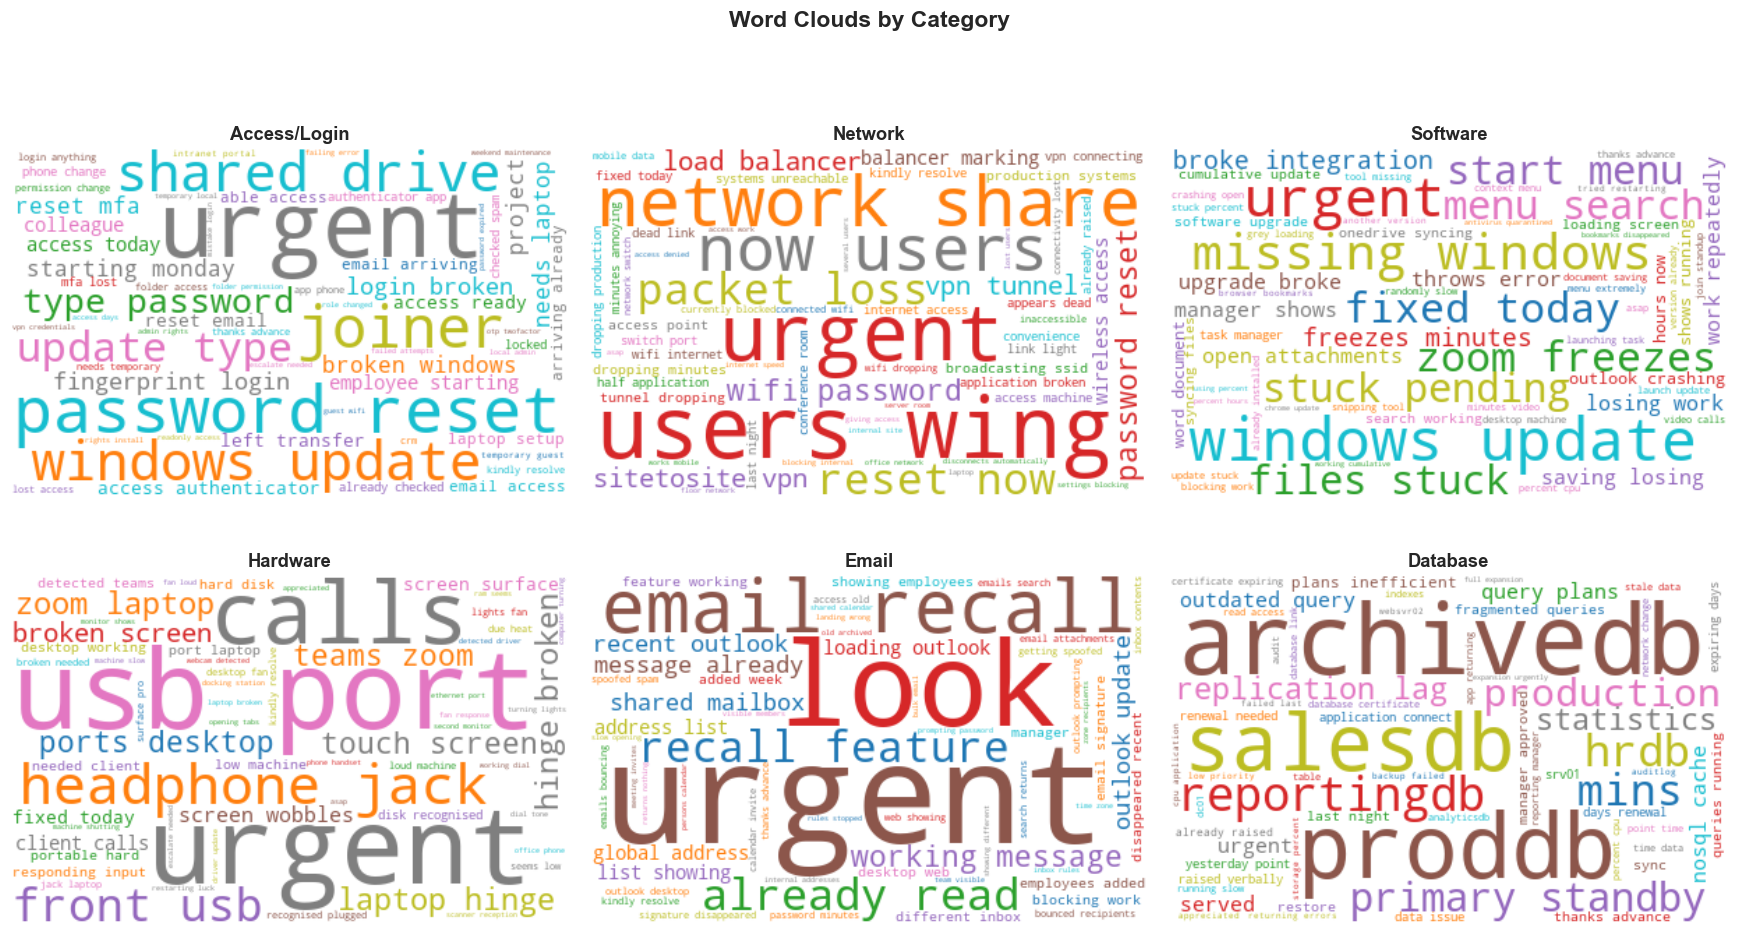

Saved: results/eda_04_word_clouds.png


In [6]:
# ── simple text cleaner for visualisation (not the full NLP pipeline) ──────────
STOPWORDS_VIZ = {
    'the','a','an','is','are','was','were','in','on','at','to','for',
    'of','and','or','not','with','my','i','it','this','that','have',
    'has','been','after','from','by','but','no','be','do','all','its',
    'as','also','just','even','when','after','since','still','very',
    'please','help','need','get','can','cannot','can\'t','keeps','keep',
    'every','few','some','any','same','both','more','other','new'
}

def clean_for_viz(text):
    """Lowercase, remove punctuation, filter stopwords."""
    tokens = re.sub(r'[^a-z0-9\s]', '', text.lower()).split()
    return [t for t in tokens if t not in STOPWORDS_VIZ and len(t) > 2]

categories = df['category'].unique()

if HAS_WORDCLOUD:
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    axes = axes.flatten()

    for ax, cat in zip(axes, categories):
        cat_texts = df[df['category'] == cat]['ticket_text'].tolist()
        all_words  = ' '.join([' '.join(clean_for_viz(t)) for t in cat_texts])
        wc = WordCloud(width=400, height=250, background_color='white',
                       max_words=60, colormap='tab10').generate(all_words)
        ax.imshow(wc, interpolation='bilinear')
        ax.set_title(cat, fontweight='bold', fontsize=12)
        ax.axis('off')

    plt.suptitle('Word Clouds by Category', fontsize=15, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.savefig(RESULTS_DIR / 'eda_04_word_clouds.png', bbox_inches='tight')
    plt.show()
    print('Saved: results/eda_04_word_clouds.png')
else:
    print('Skipped word clouds — install wordcloud: pip install wordcloud')

---
## 5. Top Word Frequencies per Category

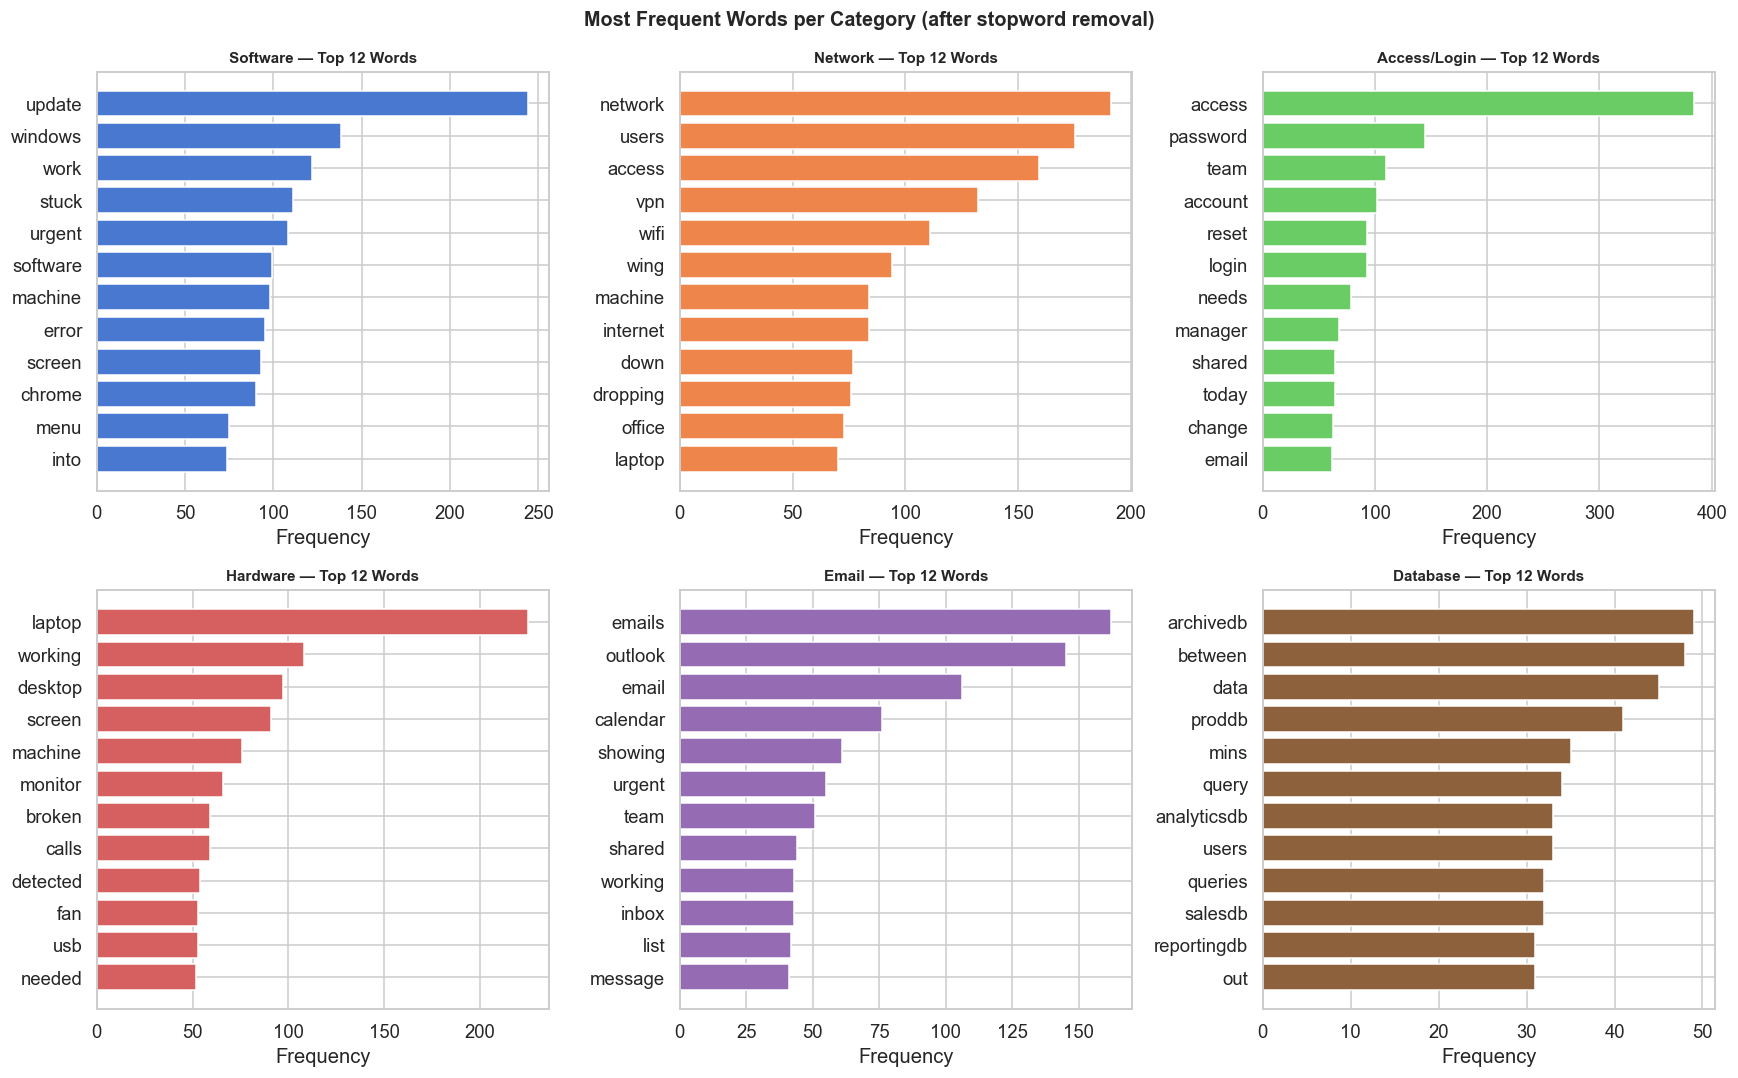

Saved: results/eda_05_word_frequencies.png


In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.flatten()

for ax, cat in zip(axes, CAT_ORDER):
    cat_texts = df[df['category'] == cat]['ticket_text'].tolist()
    words = []
    for t in cat_texts:
        words.extend(clean_for_viz(t))
    top = Counter(words).most_common(12)
    words_list, counts = zip(*top)
    ax.barh(list(reversed(words_list)), list(reversed(counts)),
            color=sns.color_palette('muted')[CAT_ORDER.index(cat)])
    ax.set_title(f'{cat} — Top 12 Words', fontweight='bold', fontsize=10)
    ax.set_xlabel('Frequency')

plt.suptitle('Most Frequent Words per Category (after stopword removal)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_05_word_frequencies.png', bbox_inches='tight')
plt.show()
print('Saved: results/eda_05_word_frequencies.png')

### Insight 4 — Vocabulary is Category-Specific (Justifies TF-IDF)

The top words per category are **distinct and non-overlapping**:
- **Network:** `vpn`, `wifi`, `internet`, `ping`, `server` — infrastructure vocabulary
- **Database:** `sql`, `query`, `table`, `backup`, `db` — DBA vocabulary
- **Access/Login:** `account`, `locked`, `password`, `access`, `login` — IAM vocabulary

This vocabulary separation means **TF-IDF will be a strong baseline** — the high-frequency domain-specific terms act as near-perfect discriminators between categories. This also explains why the Logistic Regression + TF-IDF model is competitive with Random Forest in Step 5.

---
## 6. Priority vs Resolution Time Correlation

C:\Users\Pyramid\AppData\Local\Temp\ipykernel_12212\3930120180.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df_clip, x='priority', y='resolution_time_hours',


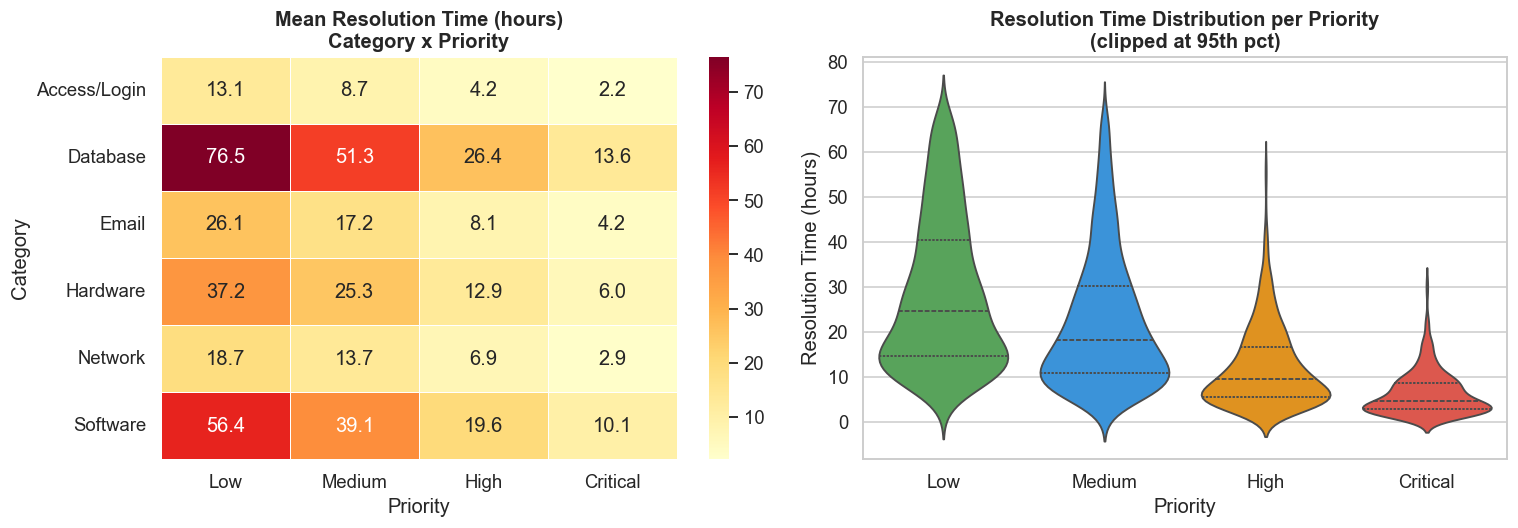

Saved: results/eda_06_priority_resolution_correlation.png

Pearson correlation (priority_rank vs resolution_hours): 0.437


In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Heatmap: mean resolution time by category × priority ──────────────────────
pivot = df.pivot_table(values='resolution_time_hours',
                        index='category', columns='priority',
                        aggfunc='mean').reindex(columns=PRI_ORDER)
sns.heatmap(pivot, annot=True, fmt='.1f', cmap='YlOrRd',
            linewidths=0.5, ax=axes[0])
axes[0].set_title('Mean Resolution Time (hours)\nCategory x Priority', fontweight='bold')
axes[0].set_xlabel('Priority')
axes[0].set_ylabel('Category')

# ── Violin plot: resolution time distribution per priority ─────────────────────
# Clip at 95th percentile so extreme outliers don't squash the violin
clip_val = df['resolution_time_hours'].quantile(0.95)
df_clip  = df[df['resolution_time_hours'] <= clip_val]
sns.violinplot(data=df_clip, x='priority', y='resolution_time_hours',
               order=PRI_ORDER,
               palette=['#4caf50','#2196f3','#ff9800','#f44336'],
               inner='quartile', ax=axes[1])
axes[1].set_title('Resolution Time Distribution per Priority\n(clipped at 95th pct)', fontweight='bold')
axes[1].set_xlabel('Priority')
axes[1].set_ylabel('Resolution Time (hours)')

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'eda_06_priority_resolution_correlation.png', bbox_inches='tight')
plt.show()
print('Saved: results/eda_06_priority_resolution_correlation.png')

# Numerical correlation
pri_map = {'Low': 4, 'Medium': 3, 'High': 2, 'Critical': 1}
corr = df['priority'].map(pri_map).corr(df['resolution_time_hours'])
print(f'\nPearson correlation (priority_rank vs resolution_hours): {corr:.3f}')

### Insight 5 — Priority and Resolution Time Are Strongly Correlated

The heatmap and correlation coefficient confirm a **strong positive relationship** between ticket priority and resolution time:
- Low-priority tickets take significantly longer to resolve than High/Critical tickets across **every** category.
- The relationship holds even within a single category (e.g., a Critical Software ticket resolves much faster than a Low Software ticket).

**Implication for modelling:**
1. The regression model (Notebook 06) should include both `category` and `priority` as features — they provide complementary signals.
2. The SLA-breach risk flag in the routing engine is valid — if we can predict priority correctly, we can reliably estimate SLA risk.

---
## EDA Summary

| # | Finding | Modelling Implication |
|---|---|---|
| 1 | Category & priority are imbalanced | Use `class_weight='balanced'` in all classifiers |
| 2 | Monday/Tuesday spike in ticket volume | Include `day_of_week` as a regression feature |
| 3 | Resolution time strongly correlated with category + priority | Both must be features in the regression model |
| 4 | Vocabulary is category-specific (distinct top words) | TF-IDF will be a strong baseline; justifies the feature engineering choice |
| 5 | Priority and resolution hours have strong linear correlation | SLA-breach risk flag is statistically grounded |

**Next:** Run `03_preprocessing_feature_engineering.ipynb`.